**Chapter 10 – Introduction to Artificial Neural Networks with Keras**

_This notebook contains all the sample code and solutions to the exercises in chapter 10._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/10_neural_nets_with_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/10_neural_nets_with_keras.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

This project requires Python 3.7 or above:

In [2]:
import sys

assert sys.version_info >= (3, 7)

It also requires Scikit-Learn ≥ 1.0.1:

In [3]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

And TensorFlow ≥ 2.8:

In [4]:
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

As we did in previous chapters, let's define the default font sizes to make the figures prettier:

In [5]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

And let's create the `images/ann` folder (if it doesn't already exist), and define the `save_fig()` function which is used through this notebook to save the figures in high-res for the book:

In [6]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "ann"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# From Biological to Artificial Neurons
## The Perceptron

In [7]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 0)  # Iris setosa

per_clf = Perceptron(random_state=42)
per_clf.fit(X, y)

X_new = [[2, 0.5], [3, 1]]
y_pred = per_clf.predict(X_new)  # predicts True and False for these 2 flowers

In [8]:
y_pred

array([ True, False])

The `Perceptron` is equivalent to a `SGDClassifier` with `loss="perceptron"`, no regularization, and a constant learning rate equal to 1:

In [9]:
# extra code – shows how to build and train a Perceptron

from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(loss="perceptron", penalty=None,
                        learning_rate="constant", eta0=1, random_state=42)
sgd_clf.fit(X, y)
assert (sgd_clf.coef_ == per_clf.coef_).all()
assert (sgd_clf.intercept_ == per_clf.intercept_).all()

When the Perceptron finds a decision boundary that properly separates the classes, it stops learning. This means that the decision boundary is often quite close to one class:

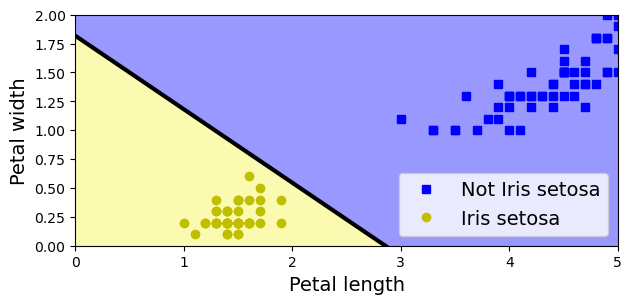

In [10]:
# extra code – plots the decision boundary of a Perceptron on the iris dataset

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

a = -per_clf.coef_[0, 0] / per_clf.coef_[0, 1]
b = -per_clf.intercept_ / per_clf.coef_[0, 1]
axes = [0, 5, 0, 2]
x0, x1 = np.meshgrid(
    np.linspace(axes[0], axes[1], 500).reshape(-1, 1),
    np.linspace(axes[2], axes[3], 200).reshape(-1, 1),
)
X_new = np.c_[x0.ravel(), x1.ravel()]
y_predict = per_clf.predict(X_new)
zz = y_predict.reshape(x0.shape)
custom_cmap = ListedColormap(['#9898ff', '#fafab0'])

plt.figure(figsize=(7, 3))
plt.plot(X[y == 0, 0], X[y == 0, 1], "bs", label="Not Iris setosa")
plt.plot(X[y == 1, 0], X[y == 1, 1], "yo", label="Iris setosa")
plt.plot([axes[0], axes[1]], [a * axes[0] + b, a * axes[1] + b], "k-",
         linewidth=3)
plt.contourf(x0, x1, zz, cmap=custom_cmap)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="lower right")
plt.axis(axes)
plt.show()

**Activation functions**

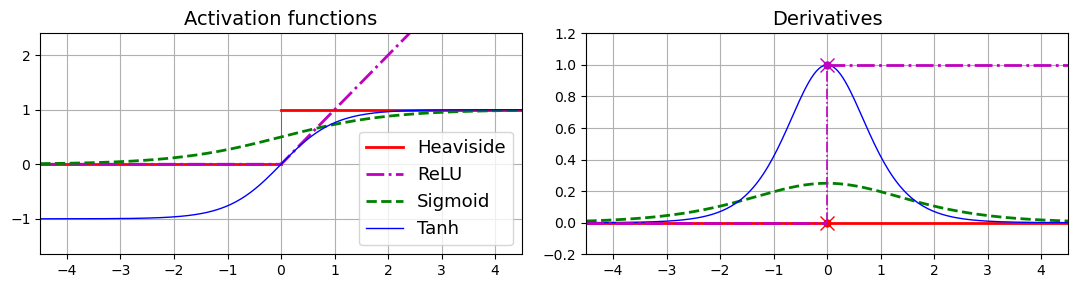

In [11]:
# extra code – this cell generates and saves Figure 10–8

from scipy.special import expit as sigmoid

def relu(z):
    return np.maximum(0, z)

def derivative(f, z, eps=0.000001):
    return (f(z + eps) - f(z - eps))/(2 * eps)

max_z = 4.5
z = np.linspace(-max_z, max_z, 200)

plt.figure(figsize=(11, 3.1))

plt.subplot(121)
plt.plot([-max_z, 0], [0, 0], "r-", linewidth=2, label="Heaviside")
plt.plot(z, relu(z), "m-.", linewidth=2, label="ReLU")
plt.plot([0, 0], [0, 1], "r-", linewidth=0.5)
plt.plot([0, max_z], [1, 1], "r-", linewidth=2)
plt.plot(z, sigmoid(z), "g--", linewidth=2, label="Sigmoid")
plt.plot(z, np.tanh(z), "b-", linewidth=1, label="Tanh")
plt.grid(True)
plt.title("Activation functions")
plt.axis([-max_z, max_z, -1.65, 2.4])
plt.gca().set_yticks([-1, 0, 1, 2])
plt.legend(loc="lower right", fontsize=13)

plt.subplot(122)
plt.plot(z, derivative(np.sign, z), "r-", linewidth=2, label="Heaviside")
plt.plot(0, 0, "ro", markersize=5)
plt.plot(0, 0, "rx", markersize=10)
plt.plot(z, derivative(sigmoid, z), "g--", linewidth=2, label="Sigmoid")
plt.plot(z, derivative(np.tanh, z), "b-", linewidth=1, label="Tanh")
plt.plot([-max_z, 0], [0, 0], "m-.", linewidth=2)
plt.plot([0, max_z], [1, 1], "m-.", linewidth=2)
plt.plot([0, 0], [0, 1], "m-.", linewidth=1.2)
plt.plot(0, 1, "mo", markersize=5)
plt.plot(0, 1, "mx", markersize=10)
plt.grid(True)
plt.title("Derivatives")
plt.axis([-max_z, max_z, -0.2, 1.2])

save_fig("activation_functions_plot")
plt.show()

## Regression MLPs

**Warning**: In recent versions of Scikit-Learn, you must use `root_mean_squared_error()` to compute the RMSE, instead of `mean_squared_error(labels, predictions, squared=False)`. The following `try`/`except` block tries to import `root_mean_squared_error`, and if it fails it just defines it.

In [12]:
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(labels, predictions):
        return mean_squared_error(labels, predictions, squared=False)

In [13]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)

mlp_reg = MLPRegressor(hidden_layer_sizes=[50, 50, 50], random_state=42)
pipeline = make_pipeline(StandardScaler(), mlp_reg)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_valid)
rmse = root_mean_squared_error(y_valid, y_pred)

In [14]:
rmse

0.5053326657968856

In [15]:
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

## Classification MLPs

In [16]:
# extra code – this was left as an exercise for the reader

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

iris = load_iris()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    iris.data, iris.target, test_size=0.1, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=42)

mlp_clf = MLPClassifier(hidden_layer_sizes=[5], max_iter=10_000,
                        random_state=42)
pipeline = make_pipeline(StandardScaler(), mlp_clf)
pipeline.fit(X_train, y_train)
accuracy = pipeline.score(X_valid, y_valid)
accuracy

1.0

# Implementing MLPs with Keras
## Building an Image Classifier Using the Sequential API
### Using Keras to load the dataset

Let's start by loading the fashion MNIST dataset. Keras has a number of functions to load popular datasets in `tf.keras.datasets`. The dataset is already split for you between a training set (60,000 images) and a test set (10,000 images), but it can be useful to split the training set further to have a validation set. We'll use 55,000 images for training, and 5,000 for validation.

In [17]:
import tensorflow as tf

fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

The training set contains 60,000 grayscale images, each 28x28 pixels:

In [18]:
X_train.shape

(55000, 28, 28)

Each pixel intensity is represented as a byte (0 to 255):

In [19]:
X_train.dtype

dtype('uint8')

Let's scale the pixel intensities down to the 0-1 range and convert them to floats, by dividing by 255:

In [20]:
X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

You can plot an image using Matplotlib's `imshow()` function, with a `'binary'`
 color map:

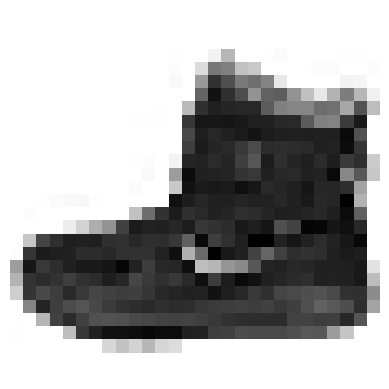

In [21]:
# extra code

plt.imshow(X_train[0], cmap="binary")
plt.axis('off')
plt.show()

The labels are the class IDs (represented as uint8), from 0 to 9:

In [22]:
y_train

array([9, 0, 0, ..., 9, 0, 2], dtype=uint8)

Here are the corresponding class names:

In [23]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

So the first image in the training set is an ankle boot:

In [24]:
class_names[y_train[0]]

'Ankle boot'

Let's take a look at a sample of the images in the dataset:

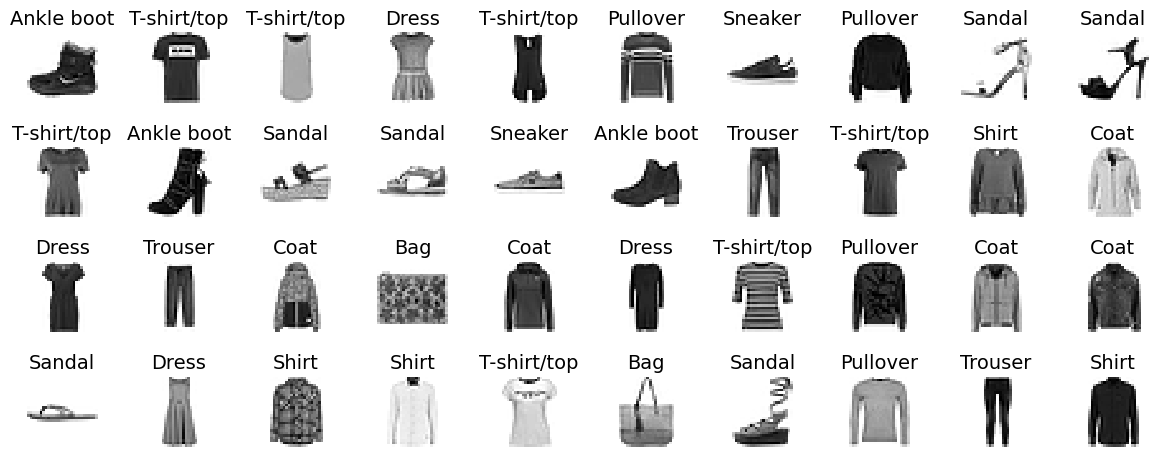

In [25]:
# extra code – this cell generates and saves Figure 10–10

n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(class_names[y_train[index]])
plt.subplots_adjust(wspace=0.2, hspace=0.5)

save_fig("fashion_mnist_plot")
plt.show()

### Creating the model using the Sequential API

In [26]:
tf.random.set_seed(42) # wyznaczenie ziarna losowości żeby uzyskać za każdym raem potwarzalne wyniki
model = tf.keras.Sequential() # stworzenie modelu sekwencyjnego (najprostszy model sieci neuronowych w Keras)
model.add(tf.keras.layers.InputLayer(input_shape=[28, 28])) # pierwsza warstwa z wymiarami - obrazki mają wymiary 28x28
model.add(tf.keras.layers.Flatten()) # przekształcenie dwuwymiarowych obrazów w jednowymiarowy wektor (28 * 28 = 784 piksele) - wartwy Dense takich oczekują
model.add(tf.keras.layers.Dense(300, activation="relu")) # warstwa ukryta składająca się z 300 neruronów, korzystająca z funkcji ReLu
model.add(tf.keras.layers.Dense(100, activation="relu")) # kolejna wartwa ukryta 100 neuronów
model.add(tf.keras.layers.Dense(10, activation="softmax")) # warstwa wyjściowa 10 neuronów - po jednym na każdą klasę (class_names powyżej)

In [27]:
# extra code – clear the session to reset the name counters
tf.keras.backend.clear_session()
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [28]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 300)               235500    
                                                                 
 dense_1 (Dense)             (None, 100)               30100     
                                                                 
 dense_2 (Dense)             (None, 10)                1010      
                                                                 
Total params: 266610 (1.02 MB)
Trainable params: 266610 (1.02 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


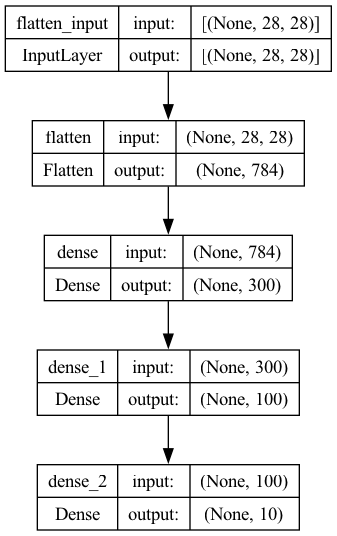

In [29]:
# extra code – another way to display the model's architecture
tf.keras.utils.plot_model(model, "my_fashion_mnist_model.png", show_shapes=True)

In [30]:
model.layers

In [31]:
hidden1 = model.layers[1]
hidden1.name

'dense'

In [32]:
model.get_layer('dense') is hidden1

True

In [33]:
weights, biases = hidden1.get_weights()
weights

array([[-1.6584992e-05, -8.6689889e-03, -4.5051649e-02, ...,
         4.2288996e-02,  5.1125675e-02, -4.5173489e-02],
       [ 2.1844342e-02, -2.2470132e-03, -3.8299788e-02, ...,
        -2.6691779e-03,  2.4439245e-03,  6.2842429e-02],
       [ 3.8227662e-02,  2.3762338e-02, -6.8263352e-02, ...,
        -1.5580151e-02, -4.9170025e-02,  6.6425428e-02],
       ...,
       [-9.7709522e-03, -3.2817904e-02, -4.4467647e-02, ...,
         5.1897720e-02, -6.4639062e-02,  5.0498217e-02],
       [-4.6133284e-02,  6.8578988e-02, -3.2418977e-02, ...,
         3.7574992e-03, -5.9750456e-02,  2.9832624e-02],
       [-2.4672449e-02, -1.2609910e-02,  1.2128420e-02, ...,
         6.2670708e-02, -3.1851493e-02, -3.1457409e-02]], dtype=float32)

In [34]:
weights.shape

(784, 300)

In [35]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [36]:
biases.shape

(300,)

### Compiling the model

In [37]:
# kompilacja modelu - określenie funkcji straty i optymalizator
model.compile(loss="sparse_categorical_crossentropy", # określenie funkcji straty, która będzie minimalizowana podczas treningu
              optimizer="sgd",
              metrics=["accuracy"])

# Dla każdej przewidywanej wartości model porównuje ją z wartością rzeczywistą za pomocą funkcji straty. 
# Wynikiem jest pojedyncza liczba, która wskazuje "wielkość błędu". 
# Im niższa wartość funkcji straty, tym lepsze dopasowanie przewidywań modelu do rzeczywistych danych.

# Korzystamy z sparse_categorical_crossentropy ponieważ mamy doczynienia z etykietami rzadkimi 
# (dla każdego przykładu występuje tylko indeks klasy docelowej - w tym przypadku od 0 do 9) - TUTAJ TRZEBA DOBRAĆ POD KONKRETNY PRZYPADEK

# Optymalizator sdg oznacza że tranujemy model za pomocą algorytmu sochastycznego spadku wzdłuż gradientu 
# - Keras przeprowadzi algorytm propagacji wstecznej

This is equivalent to:

In [38]:
# extra code – this cell is equivalent to the previous cell
model.compile(loss=tf.keras.losses.sparse_categorical_crossentropy,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=[tf.keras.metrics.sparse_categorical_accuracy])

In [39]:
# extra code – shows how to convert class ids to one-hot vectors
tf.keras.utils.to_categorical([0, 5, 1, 0], num_classes=10)

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

Note: it's important to set `num_classes` when the number of classes is greater than the maximum class id in the sample.

In [40]:
# extra code – shows how to convert one-hot vectors to class ids
np.argmax(
    [[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
     [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
     [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
     [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],
    axis=1
)

array([0, 5, 1, 0])

### Training and evaluating the model

In [41]:
# od rozpoczyna proces treningu (uczenia) wcześniej zdefiniowanego i skompilowanego modelu sieci neuronowej
# 
history = model.fit(
    X_train, # To są dane treningowe, czyli zestaw obrazów (cech), na których model będzie się uczył.
    y_train, # To są etykiety (poprawne odpowiedzi) dla danych treningowych. Model będzie starał się dopasować swoje przewidywania do tych etykiet.
    epochs=30, # (tutaj przykładowo 30 ekop - to można dostroić) Określa liczbę epok, czyli ile razy cały zestaw treningowy zostanie "przejrzany" przez model. W każdej epoce model dostosowuje swoje wagi, próbując zminimalizować funkcję straty.
    validation_data=(X_valid, y_valid) # To są dane walidacyjne, używane do oceny wydajności modelu po każdej epoce, ale bez użycia ich do aktualizacji wag. Pomaga to monitorować, czy model nie przeucza się na danych treningowych (czy nadal dobrze radzi sobie z danymi, których "nie widział" podczas głównego treningu).
)

# keras mierzy funkcję straty i dodatkowe wskaźniki na końcu każdej z epok. 
# Jeśli skuteczność modelu przewyższa wydajność dla zestawu walidacyjnego, to model prawdopodobnie uległ przetrenowaniu lub wysąpiła usterka.
# Błędy wymiarów są powszechne, zwłaszcza na początku przygody z sieciami neuronowymi, 
# dlatego dobrze jest się zapoznać z komunikatami o błedach.


Epoch 1/30
1719/1719 [==============================] - 2s 908us/step - loss: 0.7103 - sparse_categorical_accuracy: 0.7676 - val_loss: 0.5116 - val_sparse_categorical_accuracy: 0.8276
Epoch 2/30
1719/1719 [==============================] - 1s 853us/step - loss: 0.4891 - sparse_categorical_accuracy: 0.8296 - val_loss: 0.4631 - val_sparse_categorical_accuracy: 0.8362
Epoch 3/30
1719/1719 [==============================] - 2s 874us/step - loss: 0.4434 - sparse_categorical_accuracy: 0.8437 - val_loss: 0.4311 - val_sparse_categorical_accuracy: 0.8516
Epoch 4/30
1719/1719 [==============================] - 1s 857us/step - loss: 0.4183 - sparse_categorical_accuracy: 0.8536 - val_loss: 0.4019 - val_sparse_categorical_accuracy: 0.8610
Epoch 5/30
1719/1719 [==============================] - 1s 864us/step - loss: 0.3970 - sparse_categorical_accuracy: 0.8597 - val_loss: 0.4007 - val_sparse_categorical_accuracy: 0.8590
Epoch 6/30
1719/1719 [==============================] - 1s 869us/step - loss: 0.

In [42]:
history.params

{'verbose': 1, 'epochs': 30, 'steps': 1719}

In [43]:
print(history.epoch)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


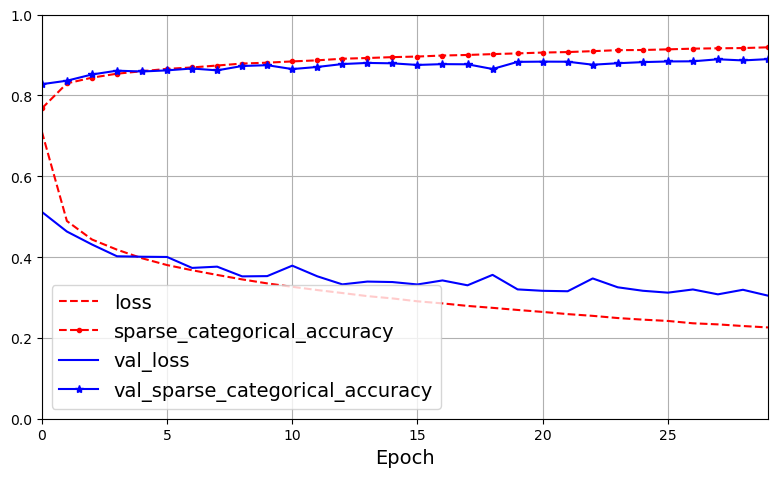

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 29], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left")  # extra code
save_fig("keras_learning_curves_plot")  # extra code
plt.show()

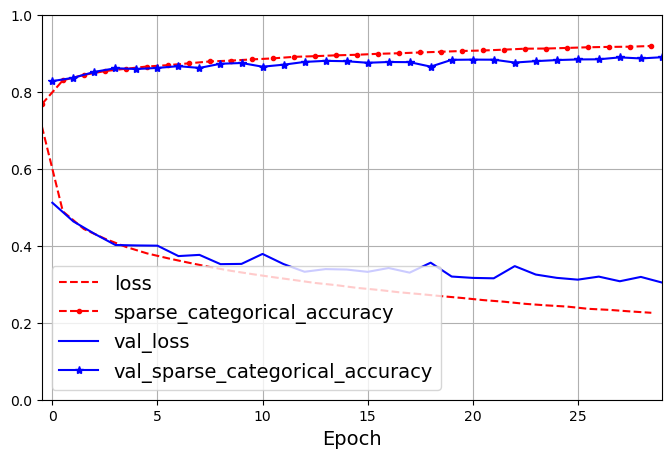

In [45]:
# extra code – shows how to shift the training curve by -1/2 epoch
plt.figure(figsize=(8, 5))
for key, style in zip(history.history, ["r--", "r--.", "b-", "b-*"]):
    epochs = np.array(history.epoch) + (0 if key.startswith("val_") else -0.5)
    plt.plot(epochs, history.history[key], style, label=key)
plt.xlabel("Epoch")
plt.axis([-0.5, 29, 0., 1])
plt.legend(loc="lower left")
plt.grid()
plt.show()

# Dokładność  dla zestawu uczącego jak i walidacyjnego rośnie w miarę uczenia - to dobrze
# Początkowo  krzywe walidacyjne znajdują się blisko siebie ale w miarę upływu czasu oddalają się od siebie - nieznaczne przetrenowanie

# Poprzedni wykres nie był dokładny bo wskazywał że na początku treningu model lepiej sprawował się wobec zbioru walidacyjnego niż uczącego
# - co nie jest prawdą - wartość blędu walidacyjnego jest obliczana na końcu każdej epoki, natomiast wartość błedu uczenia jest uzyskiwana
# przy użyciu średniej kroczącej w trakcie danej epoki, zatem krzywa została przesunięta w tym wykresie o pół epoki w lewo

In [46]:
# Uzyskaj błąd uogołnmienia na zestawie testowym

model.evaluate(X_test, y_test)

313/313 [==============================] - 0s 447us/step - loss: 0.3194 - sparse_categorical_accuracy: 0.8882


[0.31944385170936584, 0.8881999850273132]

### Using the model to make predictions

In [47]:
# predykcje dla nowych przykładów - tutaj nie mamy nowych więc użyejmy tych z zestawu testowego

X_new = X_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 [==============================] - 0s 36ms/step


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.01, 0.  , 0.01, 0.  , 0.98],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

In [48]:
# array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.01, 0.  , 0.02, 0.  , 0.97], - 97% dla pierwszego elementu że to są trzewiki
#        [0.  , 0.  , 0.99, 0.  , 0.01, 0.  , 0.  , 0.  , 0.  , 0.  ], - 99% dla drugiego elementu że to pulower/sweter
#        [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]], - 100% dla trzeciego elementu że to są spodnie
#       dtype=float32)

# class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
#                "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

y_pred = y_proba.argmax(axis=-1)
y_pred

array([9, 2, 1])

In [49]:
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [50]:
y_new = y_test[:3]
y_new

array([9, 2, 1], dtype=uint8)

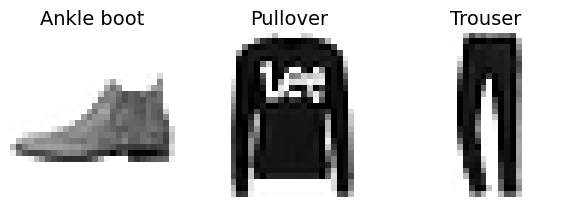

In [51]:
# extra code – this cell generates and saves Figure 10–12
plt.figure(figsize=(7.2, 2.4))
for index, image in enumerate(X_new):
    plt.subplot(1, 3, index + 1)
    plt.imshow(image, cmap="binary", interpolation="nearest")
    plt.axis('off')
    plt.title(class_names[y_test[index]])
plt.subplots_adjust(wspace=0.2, hspace=0.5)
save_fig('fashion_mnist_images_plot', tight_layout=False)
plt.show()

## Building a Regression MLP Using the Sequential API

Let's load, split and scale the California housing dataset (the original one, not the modified one as in chapter 2):

In [52]:
# extra code – load and split the California housing dataset, like earlier
housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)

In [54]:
tf.random.set_seed(42)
norm_layer = tf.keras.layers.Normalization(input_shape=X_train.shape[1:]) # Tworzy warstwę, która standaryzuje cechy wejściowe - nie zna jeszcze średniej i odchylenia – nauczy się ich później
model = tf.keras.Sequential([
    norm_layer, # Pierwsza warstwa, która normalizuje dane wejściowe.
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(1) # Warstwa wyjściowa z 1 neuronem (dla problemu regresji) i bez funkcji aktywacji (liniowa).
])
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3) # Definiuje optymalizator Adam z ustaloną szybkością uczenia (learning rate) 0.001.
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])
# model.compile() przekształca architekturę sieci w gotowy do uczenia układ optymalizacji, 
# przypinając funkcję straty, optymalizator, metryki oraz generując wewnętrzne funkcje treningu i ewaluacji.
norm_layer.adapt(X_train) # Warstwa normalizacji uczy się parametrów (średniej i wariancji) na podstawie danych treningowych `X_train`.
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))
# Trenuje model na danych treningowych (`X_train`, `y_train`) przez 20 epok.
# `validation_data` jest używane do monitorowania wydajności modelu na zbiorze walidacyjnym podczas treningu.
# Obiekt `history` zawiera informacje o stratach i metrykach w każdej epoce.
mse_test, rmse_test = model.evaluate(X_test, y_test)
# Ocenia wydajność wytrenowanego modelu na niewidzianym wcześniej zbiorze testowym (`X_test`, `y_test`).
# Zwraca wartość straty (mse_test) oraz wartość metryki RMSE (rmse_test).
X_new = X_test[:3]
# Wybiera pierwsze 3 próbki ze zbioru testowego do przewidywania.
y_pred = model.predict(X_new)
# Wykonuje przewidywania na nowych danych (`X_new`) przy użyciu wytrenowanego modelu.

Epoch 1/20
363/363 [==============================] - 0s 769us/step - loss: 1.0070 - root_mean_squared_error: 1.0035 - val_loss: 0.3829 - val_root_mean_squared_error: 0.6188
Epoch 2/20
363/363 [==============================] - 0s 591us/step - loss: 0.3834 - root_mean_squared_error: 0.6192 - val_loss: 1.8532 - val_root_mean_squared_error: 1.3613
Epoch 3/20
363/363 [==============================] - 0s 583us/step - loss: 0.3759 - root_mean_squared_error: 0.6131 - val_loss: 0.3836 - val_root_mean_squared_error: 0.6194
Epoch 4/20
363/363 [==============================] - 0s 595us/step - loss: 0.3420 - root_mean_squared_error: 0.5848 - val_loss: 0.3173 - val_root_mean_squared_error: 0.5633
Epoch 5/20
363/363 [==============================] - 0s 604us/step - loss: 0.3301 - root_mean_squared_error: 0.5745 - val_loss: 0.5083 - val_root_mean_squared_error: 0.7130
Epoch 6/20
363/363 [==============================] - 0s 581us/step - loss: 0.3184 - root_mean_squared_error: 0.5643 - val_loss: 0

In [55]:
rmse_test

0.5313493609428406

In [56]:
y_pred

array([[0.43566054],
       [1.1040212 ],
       [5.349937  ]], dtype=float32)

## Building Complex Models Using the Functional API

Not all neural network models are simply sequential. Some may have complex topologies. Some may have multiple inputs and/or multiple outputs. For example, a Wide & Deep neural network (see [paper](https://ai.google/research/pubs/pub45413)) connects all or part of the inputs directly to the output layer.

In [55]:
# extra code – reset the name counters and make the code reproducible
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [58]:
normalization_layer = tf.keras.layers.Normalization() # warstwa standaryzująca dane wejściowe
hidden_layer1 = tf.keras.layers.Dense(30, activation="relu") # 1. warstwa z 30 neuronami
hidden_layer2 = tf.keras.layers.Dense(30, activation="relu") # 2. warstwa z 30 neuronami
concat_layer = tf.keras.layers.Concatenate() # Tworzy instancję warstwy konkatenacji, która połączy ze sobą wiele wejść (tensorów) wzdłuż danej osi.
output_layer = tf.keras.layers.Dense(1) # warstwa Dense stanowiącą warstwę wyjściową, pozbawioną funkcji aktywacji

input_ = tf.keras.layers.Input(shape=X_train.shape[1:]) # warstwa do wyznaczania danych wejściowych do model, w tym wymiary, typ
normalized = normalization_layer(input_) # definiujemy tutaj sposób łączenia warstw - jest to element "symboliczny" - żadne dane nie są przetwarzane
# Przepuszcza dane wejściowe 'input_' przez warstwę normalizacji. 'normalized' jest teraz tensorem wyjściowym z tej warstwy.

hidden1 = hidden_layer1(normalized)
# Przepuszcza znormalizowane wejście przez pierwszą warstwę ukrytą. 'hidden1' to tensor wyjściowy z tej warstwy.
hidden2 = hidden_layer2(hidden1)
# Przepuszcza wyjście z 'hidden1' przez drugą warstwę ukrytą. 'hidden2' to tensor wyjściowy z tej warstwy.

concat = concat_layer([normalized, hidden2])
# Konkatenacja wyjścia z warstwy normalizacji ('normalized') z wyjściem z drugiej warstwy ukrytej ('hidden2'). 
# Proces ten jest "symboliczny" i służy jedynie do konstrułowania modelu

output = output_layer(concat)
# Przepuszcza połączony tensor ('concat') przez warstwę wyjściową, generując końcowe przewidywania modelu.

model = tf.keras.Model(inputs=[input_], outputs=[output])
# tworzy obiekt model z wyznaczeniem które wejścia i wyjścia mają być użyte

In [59]:
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 8)]                  0         []                            
                                                                                                  
 normalization_3 (Normaliza  (None, 8)                    17        ['input_2[0][0]']             
 tion)                                                                                            
                                                                                                  
 dense_14 (Dense)            (None, 30)                   270       ['normalization_3[0][0]']     
                                                                                                  
 dense_15 (Dense)            (None, 30)                   930       ['dense_14[0][0]']      

In [58]:
# reszta etapów identyczna:
# kompilacja modelu
# dostosowanie warstwy Normalization
# dopasowanie modelu
# ocena modelu
# prognozowanie modelu

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])
normalization_layer.adapt(X_train) # Warstwa normalizacji uczy się średniej i wariancji z danych treningowych
history = model.fit(X_train, y_train, epochs=20, # trening modelu
                    validation_data=(X_valid, y_valid)) 
mse_test = model.evaluate(X_test, y_test)
y_pred = model.predict(X_new)

Epoch 1/20
363/363 [==============================] - 0s 680us/step - loss: 1.3745 - root_mean_squared_error: 1.1724 - val_loss: 2.3641 - val_root_mean_squared_error: 1.5376
Epoch 2/20
363/363 [==============================] - 0s 500us/step - loss: 0.4569 - root_mean_squared_error: 0.6760 - val_loss: 0.4948 - val_root_mean_squared_error: 0.7034
Epoch 3/20
363/363 [==============================] - 0s 484us/step - loss: 0.4038 - root_mean_squared_error: 0.6355 - val_loss: 0.4565 - val_root_mean_squared_error: 0.6756
Epoch 4/20
363/363 [==============================] - 0s 492us/step - loss: 0.3833 - root_mean_squared_error: 0.6191 - val_loss: 0.5274 - val_root_mean_squared_error: 0.7262
Epoch 5/20
363/363 [==============================] - 0s 502us/step - loss: 0.3741 - root_mean_squared_error: 0.6117 - val_loss: 0.4142 - val_root_mean_squared_error: 0.6436
Epoch 6/20
363/363 [==============================] - 0s 505us/step - loss: 0.3660 - root_mean_squared_error: 0.6050 - val_loss: 0

What if you want to send different subsets of input features through the wide or deep paths? We will send 5 features (features 0 to 4), and 6 through the deep path (features 2 to 7). Note that 3 features will go through both (features 2, 3 and 4).

In [61]:
tf.random.set_seed(42)  # extra code

In [62]:
# podział cech na ścieżkę krótką i głęboką

input_wide = tf.keras.layers.Input(shape=[5])  # definicja wejścia dla ścieżki szerokiej - first features 0 to 4
input_deep = tf.keras.layers.Input(shape=[6])  # definicja wejścia dla ścieżki głębokiej - features 2 to 7
norm_layer_wide = tf.keras.layers.Normalization() # normalizacja dla ścieżki szerokiej
norm_layer_deep = tf.keras.layers.Normalization() # normalizacja dla ścieżki głębokiej 
norm_wide = norm_layer_wide(input_wide) # przeprowadzenie normalzacji dla ścieżki szerokiej
norm_deep = norm_layer_deep(input_deep) # przeprowadzenie normalzacji dla ścieżki głębokiej
hidden1 = tf.keras.layers.Dense(30, activation="relu")(norm_deep) # warstwa dla  ścieżki głębokiej
hidden2 = tf.keras.layers.Dense(30, activation="relu")(hidden1) # warstwa dla  ścieżki głębokiej
concat = tf.keras.layers.concatenate([norm_wide, hidden2])
# Konkatenacja (łączenie) wyjść z dwóch ścieżk: znormalizowanego wejścia 'szerokiej' ścieżki (norm_wide)
# oraz wyjścia z 'głębokiej' ścieżki po przejściu przez dwie warstwy ukryte (hidden2).
# To jest kluczowy element architektury Wide & Deep, gdzie dane z obu ścieżek są łączone przed warstwą wyjściową.

output = tf.keras.layers.Dense(1)(concat)
model = tf.keras.Model(inputs=[input_wide, input_deep], outputs=[output]) # określenie dwóch wyjść ponieważ mamy dwie ścieżki

In [63]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3) # definiowanie optymalizatora Adam
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"]) # kompliacja modelu

X_train_wide, X_train_deep = X_train[:, :5], X_train[:, 2:] # dzielenie danych treningowych na dwie ścieżki
X_valid_wide, X_valid_deep = X_valid[:, :5], X_valid[:, 2:] # dzielenie danych walidacyjnych na dwie ścieżki
X_test_wide, X_test_deep = X_test[:, :5], X_test[:, 2:] # dzielenie danych testowych na dwie ścieżki
X_new_wide, X_new_deep = X_test_wide[:3], X_test_deep[:3] # wybranie próbek z danych testowych do demonstracji

norm_layer_wide.adapt(X_train_wide) # Warstwa normalizacji uczy się średniej dla ścieżki szerokiej i wariancji z danych treningowych
norm_layer_deep.adapt(X_train_deep) # Warstwa normalizacji uczy się średniej dla ścieżki głębokiej i wariancji z danych treningowych
history = model.fit((X_train_wide, X_train_deep), y_train, epochs=20, #trening modelu
                    validation_data=((X_valid_wide, X_valid_deep), y_valid))
mse_test = model.evaluate((X_test_wide, X_test_deep), y_test) # ocena modelu
y_pred = model.predict((X_new_wide, X_new_deep)) # prognozy

Epoch 1/20
363/363 [==============================] - 0s 753us/step - loss: 1.8505 - root_mean_squared_error: 1.3603 - val_loss: 3.3716 - val_root_mean_squared_error: 1.8362
Epoch 2/20
363/363 [==============================] - 0s 643us/step - loss: 0.6004 - root_mean_squared_error: 0.7749 - val_loss: 1.5351 - val_root_mean_squared_error: 1.2390
Epoch 3/20
363/363 [==============================] - 0s 587us/step - loss: 0.4844 - root_mean_squared_error: 0.6960 - val_loss: 0.7967 - val_root_mean_squared_error: 0.8926
Epoch 4/20
363/363 [==============================] - 0s 591us/step - loss: 0.4322 - root_mean_squared_error: 0.6574 - val_loss: 0.5256 - val_root_mean_squared_error: 0.7250
Epoch 5/20
363/363 [==============================] - 0s 691us/step - loss: 0.3962 - root_mean_squared_error: 0.6295 - val_loss: 0.7141 - val_root_mean_squared_error: 0.8450
Epoch 6/20
363/363 [==============================] - 0s 597us/step - loss: 0.3791 - root_mean_squared_error: 0.6157 - val_loss: 0

Adding an auxiliary output for regularization:

In [64]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [65]:
# dodanie dodatkowego wyjścia
# - jeśli mamy zadanie gdzie np. musimy znaleść i zakwalifikować obiekt na zdjęciu, wtedy będziemy mieli zadanie regresyjne i klasyfikacyjne
# - klasyfikacja wielozadaniowa np. rozpoznanie mimiki twarzy oraz rozpoznanie czy ma okulary
# - technika regularyzacji - ograniczenie nauki żeby uniknąć przetrenowania - dodanie dodatkowego wyjścia tak żeby głębsza sieć rozpoznawała wzroce bez udziału pozostałej części

input_wide = tf.keras.layers.Input(shape=[5])  # features 0 to 4
input_deep = tf.keras.layers.Input(shape=[6])  # features 2 to 7
norm_layer_wide = tf.keras.layers.Normalization()
norm_layer_deep = tf.keras.layers.Normalization()
norm_wide = norm_layer_wide(input_wide)
norm_deep = norm_layer_deep(input_deep)
hidden1 = tf.keras.layers.Dense(30, activation="relu")(norm_deep)
hidden2 = tf.keras.layers.Dense(30, activation="relu")(hidden1)
concat = tf.keras.layers.concatenate([norm_wide, hidden2])
output = tf.keras.layers.Dense(1)(concat)
aux_output = tf.keras.layers.Dense(1)(hidden2)
model = tf.keras.Model(inputs=[input_wide, input_deep],
                       outputs=[output, aux_output])

**Warning**: in recent versions, Keras requires one metric per output, so I replaced `metrics=["RootMeanSquaredError"]` with `metrics=["RootMeanSquaredError", "RootMeanSquaredError"]` in the code below.

In [68]:
# każde wyjście musi mieć osobną funkcję straty - jeśli przekażemy jedną to Keras uzna że ma być ona uzywana we wszystkich warstwach wyjściowych - oblicza wtedy wszystkie funkcje i sumuje na końcu

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

# możemy zdefiniować większą wagę dla głównej funkcji straty większą wagę

model.compile(
    loss=("mse", "mse"),
    loss_weights=(0.9, 0.1),
    optimizer=optimizer,
    metrics=[
        tf.keras.metrics.RootMeanSquaredError(name="rmse_main"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse_aux"),
    ],
)


In [69]:
norm_layer_wide.adapt(X_train_wide)  # Warstwa normalizacji uczy się średniej dla ścieżki szerokiej i wariancji z danych treningowych
norm_layer_deep.adapt(X_train_deep)  # Warstwa normalizacji uczy się średniej dla ścieżki głębokiej i wariancji z danych treningowych
history = model.fit( # trening modelu
    (X_train_wide, X_train_deep), (y_train, y_train), epochs=20,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid))
)

Epoch 1/20
363/363 [==============================] - 1s 993us/step - loss: 1.5192 - dense_2_loss: 1.4837 - dense_3_loss: 1.8388 - dense_2_rmse_main: 1.2181 - dense_2_rmse_aux: 1.2181 - dense_3_rmse_main: 1.3560 - dense_3_rmse_aux: 1.3560 - val_loss: 0.7634 - val_dense_2_loss: 0.6232 - val_dense_3_loss: 2.0247 - val_dense_2_rmse_main: 0.7894 - val_dense_2_rmse_aux: 0.7894 - val_dense_3_rmse_main: 1.4229 - val_dense_3_rmse_aux: 1.4229
Epoch 2/20
363/363 [==============================] - 0s 730us/step - loss: 0.5603 - dense_2_loss: 0.5456 - dense_3_loss: 0.6924 - dense_2_rmse_main: 0.7386 - dense_2_rmse_aux: 0.7386 - dense_3_rmse_main: 0.8321 - dense_3_rmse_aux: 0.8321 - val_loss: 0.8976 - val_dense_2_loss: 0.8971 - val_dense_3_loss: 0.9026 - val_dense_2_rmse_main: 0.9471 - val_dense_2_rmse_aux: 0.9471 - val_dense_3_rmse_main: 0.9501 - val_dense_3_rmse_aux: 0.9501
Epoch 3/20
363/363 [==============================] - 0s 732us/step - loss: 0.4881 - dense_2_loss: 0.4755 - dense_3_loss: 0.

**Warning**: in recent TF version, `evaluate()` also returns the main metric and the aux metric. To ensure the code works in both old and new versions, we only look at the first 3 elements of `eval_results` (i.e., just the losses):

In [76]:
eval_results = model.evaluate((X_test_wide, X_test_deep), (y_test, y_test)) # ocena modelu
print('---')
weighted_sum_of_losses, main_loss, aux_loss, main_rmse, additional_rmse = eval_results[:5]
print(weighted_sum_of_losses, main_loss, aux_loss, main_rmse, additional_rmse)

162/162 [==============================] - 0s 538us/step - loss: 0.3404 - dense_2_loss: 0.3337 - dense_3_loss: 0.4006 - dense_2_rmse_main: 0.5777 - dense_2_rmse_aux: 0.5777 - dense_3_rmse_main: 0.6329 - dense_3_rmse_aux: 0.6329
---
0.3404214382171631 0.3337373733520508 0.4005798399448395 0.5777000784873962 0.5777000784873962


In [77]:
y_pred_main, y_pred_aux = model.predict((X_new_wide, X_new_deep)) # prognozy

1/1 [==============================] - 0s 15ms/step


In [79]:
y_pred_tuple = model.predict((X_new_wide, X_new_deep))
y_pred = dict(zip(model.output_names, y_pred_tuple))

print(y_pred_tuple)
print('--------')
print(y_pred)

1/1 [==============================] - 0s 17ms/step
[array([[0.4123698],
       [1.2759179],
       [3.4819863]], dtype=float32), array([[0.5580668],
       [1.3341353],
       [3.2534213]], dtype=float32)]
--------
{'dense_2': array([[0.4123698],
       [1.2759179],
       [3.4819863]], dtype=float32), 'dense_3': array([[0.5580668],
       [1.3341353],
       [3.2534213]], dtype=float32)}


## Using the Subclassing API to Build Dynamic Models

In [69]:
class WideAndDeepModel(tf.keras.Model):
    def __init__(self, units=30, activation="relu", **kwargs):
        super().__init__(**kwargs)  # needed to support naming the model
        self.norm_layer_wide = tf.keras.layers.Normalization()
        self.norm_layer_deep = tf.keras.layers.Normalization()
        self.hidden1 = tf.keras.layers.Dense(units, activation=activation)
        self.hidden2 = tf.keras.layers.Dense(units, activation=activation)
        self.main_output = tf.keras.layers.Dense(1)
        self.aux_output = tf.keras.layers.Dense(1)
        
    def call(self, inputs):
        input_wide, input_deep = inputs
        norm_wide = self.norm_layer_wide(input_wide)
        norm_deep = self.norm_layer_deep(input_deep)
        hidden1 = self.hidden1(norm_deep)
        hidden2 = self.hidden2(hidden1)
        concat = tf.keras.layers.concatenate([norm_wide, hidden2])
        output = self.main_output(concat)
        aux_output = self.aux_output(hidden2)
        return output, aux_output

tf.random.set_seed(42)  # extra code – just for reproducibility
model = WideAndDeepModel(30, activation="relu", name="my_cool_model")

**Warning**: as explained above, Keras now requires one loss and one metric per output, so I replaced `loss="mse"` with `loss=["mse", "mse"]` and I also replaced `metrics=["RootMeanSquaredError"]` with `metrics=["RootMeanSquaredError", "RootMeanSquaredError"]` in the code below.

In [70]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

# model.compile(loss=["mse", "mse"], loss_weights=[0.9, 0.1], optimizer=optimizer,
#               metrics=["RootMeanSquaredError", "RootMeanSquaredError"])

model.compile(
    loss=("mse", "mse"),
    loss_weights=(0.9, 0.1),
    optimizer=optimizer,
    metrics=[
        tf.keras.metrics.RootMeanSquaredError(name="rmse_main"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse_aux"),
    ],
)

model.norm_layer_wide.adapt(X_train_wide)
model.norm_layer_deep.adapt(X_train_deep)
history = model.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs=10,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)))
eval_results = model.evaluate((X_test_wide, X_test_deep), (y_test, y_test))
y_pred_main, y_pred_aux = model.predict((X_new_wide, X_new_deep))

Epoch 1/10
363/363 [==============================] - 1s 920us/step - loss: 1.4238 - output_1_loss: 1.3812 - output_2_loss: 1.8075 - output_1_rmse_main: 1.1752 - output_1_rmse_aux: 1.1752 - output_2_rmse_main: 1.3444 - output_2_rmse_aux: 1.3444 - val_loss: 3.0429 - val_output_1_loss: 3.0668 - val_output_2_loss: 2.8275 - val_output_1_rmse_main: 1.7512 - val_output_1_rmse_aux: 1.7512 - val_output_2_rmse_main: 1.6815 - val_output_2_rmse_aux: 1.6815
Epoch 2/10
363/363 [==============================] - 0s 647us/step - loss: 0.5383 - output_1_loss: 0.5099 - output_2_loss: 0.7934 - output_1_rmse_main: 0.7141 - output_1_rmse_aux: 0.7141 - output_2_rmse_main: 0.8907 - output_2_rmse_aux: 0.8907 - val_loss: 2.4313 - val_output_1_loss: 2.5520 - val_output_2_loss: 1.3446 - val_output_1_rmse_main: 1.5975 - val_output_1_rmse_aux: 1.5975 - val_output_2_rmse_main: 1.1595 - val_output_2_rmse_aux: 1.1595
Epoch 3/10
363/363 [==============================] - 0s 654us/step - loss: 0.4579 - output_1_loss: 

1/1 [==============================] - 0s 27ms/step


## Saving and Restoring a Model

**Warning**: Keras now recommends using the `.keras` format to save models, and the `h5` format for weights. Therefore I have updated the code in this section to first show what you need to change if you still want to use TensorFlow's `SavedModel` format, and then how you can use the recommended formats.

In [71]:
# extra code – delete the directory, in case it already exists

import shutil

shutil.rmtree("my_keras_model", ignore_errors=True)

**Warning**: Keras's `model.save()` method no longer supports TensorFlow's `SavedModel` format. However, you can still export models to the `SavedModel` format using `model.export()` like this:

In [72]:
model.export("my_keras_model")

INFO:tensorflow:Assets written to: my_keras_model/assets


INFO:tensorflow:Assets written to: my_keras_model/assets


Saved artifact at 'my_keras_model'. The following endpoints are available:

* Endpoint 'serve'
  Args:
    args_0: (<1>, <2>)
      <1>: float32 Tensor, shape=(None, 5)
      <2>: float32 Tensor, shape=(None, 6)
  Returns:
    (<1>, <2>)
      <1>: float32 Tensor, shape=(None, 1)
      <2>: float32 Tensor, shape=(None, 1)


In [73]:
# extra code – show the contents of the my_keras_model/ directory
for path in sorted(Path("my_keras_model").glob("**/*")):
    print(path)

my_keras_model/assets
my_keras_model/fingerprint.pb
my_keras_model/saved_model.pb
my_keras_model/variables
my_keras_model/variables/variables.data-00000-of-00001
my_keras_model/variables/variables.index


**Warning**: In Keras 3, it is no longer possible to load a TensorFlow `SavedModel` as a Keras model. However, you can load a `SavedModel` as a `tf.keras.layers.TFSMLayer` layer, but be aware that this layer can only be used for inference: no training.

In [74]:
import tensorflow as tf
print(tf.__version__)


2.14.1


In [75]:
# loaded_model = tf.keras.models.load_model("my_keras_model")
# y_pred_main, y_pred_aux = loaded_model((X_new_wide.astype("float32"), X_new_deep.astype("float32")), training=False)

import tensorflow as tf

# 1. Załaduj wyeksportowany SavedModel
exported = tf.saved_model.load("my_keras_model")

# 2. Sprawdź dostępne sygnatury
print("Signatures:", list(exported.signatures.keys()))

# 3. Pobierz funkcję inferencji
infer = exported.signatures["serving_default"]

# (opcjonalnie – diagnostyka)
print("Input signature:", infer.structured_input_signature)
print("Outputs:", infer.structured_outputs)

# 4. Dopasuj wejścia po nazwach z signature
inputs = infer.structured_input_signature[1]
keys = list(inputs.keys())
print("Input keys:", keys)

# 5. Wykonaj predykcję
out = infer(**{
    keys[0]: tf.constant(X_new_wide, dtype=tf.float32),
    keys[1]: tf.constant(X_new_deep, dtype=tf.float32),
})


print("Output keys:", list(out.keys()))

# 6. Rozpakuj dwa wyjścia (main + aux)
out_keys = list(out.keys())
y_pred_main = out[out_keys[0]].numpy()
y_pred_aux  = out[out_keys[1]].numpy()


Signatures: ['serve', 'serving_default']
Input signature: ((), {'input_1': TensorSpec(shape=(None, 5), dtype=tf.float32, name='input_1'), 'input_2': TensorSpec(shape=(None, 6), dtype=tf.float32, name='input_2')})
Outputs: {'output_1': TensorSpec(shape=(None, 1), dtype=tf.float32, name='output_1'), 'output_0': TensorSpec(shape=(None, 1), dtype=tf.float32, name='output_0')}
Input keys: ['input_1', 'input_2']
Output keys: ['output_1', 'output_0']


**Warning**: Keras now requires the saved weights to have the `.weights.h5` extension. There are no longer saved using the `SavedModel` format.

In [76]:
model.save_weights("my_weights.weights.h5")

In [77]:
model.load_weights("my_weights.weights.h5")

To save a model using the `.keras` format, simply use `model.save()`:

In [78]:
model.save("my_model.keras")

To load a `.keras` model, use the `tf.keras.models.load_model()` function. If the model uses any custom object, you must pass them to the function via the `custom_objects` argument:

In [79]:
loaded_model = tf.keras.models.load_model(
    "my_model.keras",
    custom_objects={"WideAndDeepModel": WideAndDeepModel}
)

## Using Callbacks

In [80]:
shutil.rmtree("my_checkpoints", ignore_errors=True)  # extra code

**Warning**: as explained earlier, Keras now requires the checkpoint files to have a `.weights.h5` extension:

In [81]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("my_checkpoints.weights.h5",
                                                   save_weights_only=True)
history = model.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs=10,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)),
    callbacks=[checkpoint_cb])

Epoch 1/10
363/363 [==============================] - 0s 714us/step - loss: 0.3575 - output_1_loss: 0.3497 - output_2_loss: 0.4273 - output_1_rmse_main: 0.5914 - output_1_rmse_aux: 0.5914 - output_2_rmse_main: 0.6537 - output_2_rmse_aux: 0.6537 - val_loss: 0.5834 - val_output_1_loss: 0.5805 - val_output_2_loss: 0.6089 - val_output_1_rmse_main: 0.7619 - val_output_1_rmse_aux: 0.7619 - val_output_2_rmse_main: 0.7803 - val_output_2_rmse_aux: 0.7803
Epoch 2/10
363/363 [==============================] - 0s 681us/step - loss: 0.3598 - output_1_loss: 0.3526 - output_2_loss: 0.4241 - output_1_rmse_main: 0.5938 - output_1_rmse_aux: 0.5938 - output_2_rmse_main: 0.6512 - output_2_rmse_aux: 0.6512 - val_loss: 1.2897 - val_output_1_loss: 1.2869 - val_output_2_loss: 1.3153 - val_output_1_rmse_main: 1.1344 - val_output_1_rmse_aux: 1.1344 - val_output_2_rmse_main: 1.1469 - val_output_2_rmse_aux: 1.1469
Epoch 3/10
363/363 [==============================] - 0s 750us/step - loss: 0.3527 - output_1_loss: 

In [82]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=10,
                                                     restore_best_weights=True)
history = model.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs=100,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)),
    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
363/363 [==============================] - 0s 703us/step - loss: 0.3380 - output_1_loss: 0.3314 - output_2_loss: 0.3978 - output_1_rmse_main: 0.5757 - output_1_rmse_aux: 0.5757 - output_2_rmse_main: 0.6307 - output_2_rmse_aux: 0.6307 - val_loss: 0.5428 - val_output_1_loss: 0.5214 - val_output_2_loss: 0.7357 - val_output_1_rmse_main: 0.7221 - val_output_1_rmse_aux: 0.7221 - val_output_2_rmse_main: 0.8577 - val_output_2_rmse_aux: 0.8577
Epoch 2/100
363/363 [==============================] - 0s 688us/step - loss: 0.3362 - output_1_loss: 0.3304 - output_2_loss: 0.3887 - output_1_rmse_main: 0.5748 - output_1_rmse_aux: 0.5748 - output_2_rmse_main: 0.6235 - output_2_rmse_aux: 0.6235 - val_loss: 1.4345 - val_output_1_loss: 1.4145 - val_output_2_loss: 1.6137 - val_output_1_rmse_main: 1.1893 - val_output_1_rmse_aux: 1.1893 - val_output_2_rmse_main: 1.2703 - val_output_2_rmse_aux: 1.2703
Epoch 3/100
363/363 [==============================] - 0s 680us/step - loss: 0.3331 - output_1_los

In [83]:
class PrintValTrainRatioCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        ratio = logs["val_loss"] / logs["loss"]
        print(f"Epoch={epoch}, val/train={ratio:.2f}")

In [84]:
val_train_ratio_cb = PrintValTrainRatioCallback()
history = model.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs=10,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)),
    callbacks=[val_train_ratio_cb], verbose=0)

Epoch=0, val/train=2.10
Epoch=1, val/train=1.00
Epoch=2, val/train=3.46
Epoch=3, val/train=1.47
Epoch=4, val/train=4.53
Epoch=5, val/train=0.96
Epoch=6, val/train=5.17
Epoch=7, val/train=1.93
Epoch=8, val/train=3.05
Epoch=9, val/train=0.95


## Using TensorBoard for Visualization

TensorBoard is preinstalled on Colab, but not the `tensorboard-plugin-profile`, so let's install it:

In [85]:
if "google.colab" in sys.modules:  # extra code
    %pip install -q -U tensorboard-plugin-profile

In [86]:
shutil.rmtree("my_logs", ignore_errors=True)

In [87]:
from pathlib import Path
from time import strftime

def get_run_logdir(root_logdir="my_logs"):
    return Path(root_logdir) / strftime("run_%Y_%m_%d_%H_%M_%S")

run_logdir = get_run_logdir()

In [88]:
# extra code – builds the first regression model we used earlier
tf.keras.backend.clear_session()
tf.random.set_seed(42)
norm_layer = tf.keras.layers.Normalization(input_shape=X_train.shape[1:])
model = tf.keras.Sequential([
    norm_layer,
    tf.keras.layers.Dense(30, activation="relu"),
    tf.keras.layers.Dense(30, activation="relu"),
    tf.keras.layers.Dense(1)
])
optimizer = tf.keras.optimizers.SGD(learning_rate=1e-3)
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])
norm_layer.adapt(X_train)

In [89]:
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir,
                                                profile_batch=(100, 200))
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid),
                    callbacks=[tensorboard_cb])

Epoch 1/20


2025-12-30 13:12:54.166278: I tensorflow/tsl/profiler/lib/profiler_session.cc:104] Profiler session initializing.
2025-12-30 13:12:54.166286: I tensorflow/tsl/profiler/lib/profiler_session.cc:119] Profiler session started.
2025-12-30 13:12:54.166393: I tensorflow/tsl/profiler/lib/profiler_session.cc:131] Profiler session tear down.


329/363 [==========================>...] - ETA: 0s - loss: 2.2047 - root_mean_squared_error: 1.4848

2025-12-30 13:12:54.369120: I tensorflow/tsl/profiler/lib/profiler_session.cc:104] Profiler session initializing.
2025-12-30 13:12:54.369130: I tensorflow/tsl/profiler/lib/profiler_session.cc:119] Profiler session started.
2025-12-30 13:12:54.412429: I tensorflow/tsl/profiler/lib/profiler_session.cc:70] Profiler session collecting data.
2025-12-30 13:12:54.424950: I tensorflow/tsl/profiler/lib/profiler_session.cc:131] Profiler session tear down.
2025-12-30 13:12:54.427056: I tensorflow/tsl/profiler/rpc/client/save_profile.cc:144] Collecting XSpace to repository: my_logs/run_2025_12_30_13_12_54/plugins/profile/2025_12_30_13_12_54/Y12R57GL4W.xplane.pb


363/363 [==============================] - 0s 726us/step - loss: 2.0930 - root_mean_squared_error: 1.4467 - val_loss: 1.6351 - val_root_mean_squared_error: 1.2787
Epoch 2/20
363/363 [==============================] - 0s 517us/step - loss: 0.8155 - root_mean_squared_error: 0.9030 - val_loss: 0.8679 - val_root_mean_squared_error: 0.9316
Epoch 3/20
363/363 [==============================] - 0s 507us/step - loss: 0.7333 - root_mean_squared_error: 0.8563 - val_loss: 0.6827 - val_root_mean_squared_error: 0.8263
Epoch 4/20
363/363 [==============================] - 0s 510us/step - loss: 0.6923 - root_mean_squared_error: 0.8320 - val_loss: 0.6510 - val_root_mean_squared_error: 0.8068
Epoch 5/20
363/363 [==============================] - 0s 513us/step - loss: 0.6603 - root_mean_squared_error: 0.8126 - val_loss: 0.6145 - val_root_mean_squared_error: 0.7839
Epoch 6/20
363/363 [==============================] - 0s 513us/step - loss: 0.6314 - root_mean_squared_error: 0.7946 - val_loss: 0.5881 - val

In [90]:
print("my_logs")
for path in sorted(Path("my_logs").glob("**/*")):
    print("  " * (len(path.parts) - 1) + path.parts[-1])

my_logs
  run_2025_12_30_13_12_54
    plugins
      profile
        2025_12_30_13_12_54
          Y12R57GL4W.xplane.pb
    train
      events.out.tfevents.1767096774.Y12R57GL4W.29794.0.v2
    validation
      events.out.tfevents.1767096774.Y12R57GL4W.29794.1.v2


Let's load the `tensorboard` Jupyter extension and start the TensorBoard server: 

In [91]:
%load_ext tensorboard
%tensorboard --logdir=./my_logs

ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
/opt/homebrew/anaconda3/envs/homl3/lib/python3.10/site-packages/tensorboard/default.py:30: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Address already in use
Port 6006 is in use by another program. Either identify and stop that program, or start the server with a different port.

In [92]:
!kill 72777

zsh:kill:1: kill 72777 failed: no such process


**Note**: if you prefer to access TensorBoard in a separate tab, click the "localhost:6006" link below:

In [93]:
# extra code

if "google.colab" in sys.modules:
    from google.colab import output

    output.serve_kernel_port_as_window(6006)
else:
    from IPython.display import display, HTML

    display(HTML('<a href="http://localhost:6006/">http://localhost:6006/</a>'))

You can use also visualize histograms, images, text, and even listen to audio using TensorBoard:

In [94]:
test_logdir = get_run_logdir()
writer = tf.summary.create_file_writer(str(test_logdir))
with writer.as_default():
    for step in range(1, 1000 + 1):
        tf.summary.scalar("my_scalar", np.sin(step / 10), step=step)
        
        data = (np.random.randn(100) + 2) * step / 100  # gets larger
        tf.summary.histogram("my_hist", data, buckets=50, step=step)
        
        images = np.random.rand(2, 32, 32, 3) * step / 1000  # gets brighter
        tf.summary.image("my_images", images, step=step)
        
        texts = ["The step is " + str(step), "Its square is " + str(step ** 2)]
        tf.summary.text("my_text", texts, step=step)
        
        sine_wave = tf.math.sin(tf.range(12000) / 48000 * 2 * np.pi * step)
        audio = tf.reshape(tf.cast(sine_wave, tf.float32), [1, -1, 1])
        tf.summary.audio("my_audio", audio, sample_rate=48000, step=step)

**Note**: it used to be possible to easily share your TensorBoard logs with the world by uploading them to https://tensorboard.dev/. Sadly, this service will shut down in December 2023, so I have removed the corresponding code examples from this notebook.

When you stop this Jupyter kernel (a.k.a. Runtime), it will automatically stop the TensorBoard server as well. Another way to stop the TensorBoard server is to kill it, if you are running on Linux or MacOSX. First, you need to find its process ID:

In [95]:
# extra code – lists all running TensorBoard server instances

from tensorboard import notebook

notebook.list()

Known TensorBoard instances:
  - port 6006: logdir my_fashion_mnist/hyperband/tensorboard (started 18:44:27 ago; pid 14199)


Next you can use the following command on Linux or MacOSX, replacing `<pid>` with the pid listed above:

    !kill <pid>

On Windows:

    !taskkill /F /PID <pid>

# Fine-Tuning Neural Network Hyperparameters

In this section we'll use the Fashion MNIST dataset again:

In [96]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [97]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [98]:
if "google.colab" in sys.modules:
    %pip install -q -U keras_tuner~=1.4.6

In [99]:
import keras_tuner as kt

def build_model(hp):
    n_hidden = hp.Int("n_hidden", min_value=0, max_value=8, default=2)
    n_neurons = hp.Int("n_neurons", min_value=16, max_value=256)
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2,
                             sampling="log")
    optimizer = hp.Choice("optimizer", values=["sgd", "adam"])
    if optimizer == "sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Flatten())
    for _ in range(n_hidden):
        model.add(tf.keras.layers.Dense(n_neurons, activation="relu"))
    model.add(tf.keras.layers.Dense(10, activation="softmax"))
    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
                  metrics=["accuracy"])
    return model

In [100]:
random_search_tuner = kt.RandomSearch(
    build_model, objective="val_accuracy", max_trials=5, overwrite=True,
    directory="my_fashion_mnist", project_name="my_rnd_search", seed=42)
random_search_tuner.search(X_train, y_train, epochs=10,
                           validation_data=(X_valid, y_valid))

Trial 5 Complete [00h 00m 12s]
val_accuracy: 0.8370000123977661

Best val_accuracy So Far: 0.8600000143051147
Total elapsed time: 00h 01m 06s


In [101]:
top3_models = random_search_tuner.get_best_models(num_models=3)
best_model = top3_models[0]

In [102]:
top3_params = random_search_tuner.get_best_hyperparameters(num_trials=3)
top3_params[0].values  # best hyperparameter values

{'n_hidden': 7,
 'n_neurons': 100,
 'learning_rate': 0.0012482904754698163,
 'optimizer': 'sgd'}

In [103]:
best_trial = random_search_tuner.oracle.get_best_trials(num_trials=1)[0]
best_trial.summary()

Trial 1 summary
Hyperparameters:
n_hidden: 7
n_neurons: 100
learning_rate: 0.0012482904754698163
optimizer: sgd
Score: 0.8600000143051147


In [104]:
best_trial.metrics.get_last_value("val_accuracy")

0.8600000143051147

In [105]:
best_model.fit(X_train_full, y_train_full, epochs=10)
test_loss, test_accuracy = best_model.evaluate(X_test, y_test)

Epoch 1/10
1875/1875 [==============================] - 2s 792us/step - loss: 0.3309 - accuracy: 0.8785
Epoch 2/10
1875/1875 [==============================] - 1s 784us/step - loss: 0.3220 - accuracy: 0.8805
Epoch 3/10
1875/1875 [==============================] - 1s 793us/step - loss: 0.3125 - accuracy: 0.8858
Epoch 4/10
1875/1875 [==============================] - 1s 798us/step - loss: 0.3057 - accuracy: 0.8865
Epoch 5/10
1875/1875 [==============================] - 1s 793us/step - loss: 0.2994 - accuracy: 0.8888
Epoch 6/10
1875/1875 [==============================] - 1s 789us/step - loss: 0.2925 - accuracy: 0.8921
Epoch 7/10
1875/1875 [==============================] - 1s 797us/step - loss: 0.2865 - accuracy: 0.8943
Epoch 8/10
1875/1875 [==============================] - 1s 799us/step - loss: 0.2808 - accuracy: 0.8959
Epoch 9/10
1875/1875 [==============================] - 2s 809us/step - loss: 0.2752 - accuracy: 0.8980
Epoch 10/10
313/313 [==============================] - 0s 468us/

In [106]:
class MyClassificationHyperModel(kt.HyperModel):
    def build(self, hp):
        return build_model(hp)

    def fit(self, hp, model, X, y, **kwargs):
        if hp.Boolean("normalize"):
            norm_layer = tf.keras.layers.Normalization()
            norm_layer.adapt(X)
            X = norm_layer(X)
        return model.fit(X, y, **kwargs)

In [107]:
hyperband_tuner = kt.Hyperband(
    MyClassificationHyperModel(), objective="val_accuracy", seed=42,
    max_epochs=10, factor=3, hyperband_iterations=2,
    overwrite=True, directory="my_fashion_mnist", project_name="hyperband")

In [108]:
root_logdir = Path(hyperband_tuner.project_dir) / "tensorboard"
tensorboard_cb = tf.keras.callbacks.TensorBoard(root_logdir)
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=2)
hyperband_tuner.search(X_train, y_train, epochs=10,
                       validation_data=(X_valid, y_valid),
                       callbacks=[early_stopping_cb, tensorboard_cb])

Trial 60 Complete [00h 00m 14s]
val_accuracy: 0.8528000116348267

Best val_accuracy So Far: 0.8762000203132629
Total elapsed time: 00h 06m 58s


In [109]:
bayesian_opt_tuner = kt.BayesianOptimization(
    MyClassificationHyperModel(), objective="val_accuracy", seed=42,
    max_trials=10, alpha=1e-4, beta=2.6,
    overwrite=True, directory="my_fashion_mnist", project_name="bayesian_opt")
bayesian_opt_tuner.search(X_train, y_train, epochs=10,
                          validation_data=(X_valid, y_valid),
                          callbacks=[early_stopping_cb])

Trial 10 Complete [00h 00m 12s]
val_accuracy: 0.8429999947547913

Best val_accuracy So Far: 0.8640000224113464
Total elapsed time: 00h 01m 50s


In [110]:
%tensorboard --logdir {root_logdir}

Reusing TensorBoard on port 6006 (pid 14199), started 18:54:37 ago. (Use '!kill 14199' to kill it.)

# Exercise solutions

## 1. to 9.

1. Visit the [TensorFlow Playground](https://playground.tensorflow.org/) and play around with it, as described in this exercise.
2. Here is a neural network based on the original artificial neurons that computes _A_ ⊕ _B_ (where ⊕ represents the exclusive OR), using the fact that _A_ ⊕ _B_ = (_A_ ∧ ¬ _B_) ∨ (¬ _A_ ∧ _B_). There are other solutions—for example, using the fact that _A_ ⊕ _B_ = (_A_ ∨ _B_) ∧ ¬(_A_ ∧ _B_), or the fact that _A_ ⊕ _B_ = (_A_ ∨ _B_) ∧ (¬ _A_ ∨ ¬ _B_), and so on.<br /><img width="70%" src="images/ann/exercise2.png" />
3. A classical Perceptron will converge only if the dataset is linearly separable, and it won't be able to estimate class probabilities. In contrast, a Logistic Regression classifier will generally converge to a reasonably good solution even if the dataset is not linearly separable, and it will output class probabilities. If you change the Perceptron's activation function to the sigmoid activation function (or the softmax activation function if there are multiple neurons), and if you train it using Gradient Descent (or some other optimization algorithm minimizing the cost function, typically cross entropy), then it becomes equivalent to a Logistic Regression classifier.
4. The sigmoid activation function was a key ingredient in training the first MLPs because its derivative is always nonzero, so Gradient Descent can always roll down the slope. When the activation function is a step function, Gradient Descent cannot move, as there is no slope at all.
5. Popular activation functions include the step function, the sigmoid function, the hyperbolic tangent (tanh) function, and the Rectified Linear Unit (ReLU) function (see Figure 10-8). See Chapter 11 for other examples, such as ELU and variants of the ReLU function.
6. Considering the MLP described in the question, composed of one input layer with 10 passthrough neurons, followed by one hidden layer with 50 artificial neurons, and finally one output layer with 3 artificial neurons, where all artificial neurons use the ReLU activation function:
    * The shape of the input matrix **X** is _m_ × 10, where _m_ represents the training batch size.
    * The shape of the hidden layer's weight matrix **W**<sub>_h_</sub> is 10 × 50, and the length of its bias vector **b**<sub>_h_</sub> is 50.
    * The shape of the output layer's weight matrix **W**<sub>_o_</sub> is 50 × 3, and the length of its bias vector **b**<sub>_o_</sub> is 3.
    * The shape of the network's output matrix **Y** is _m_ × 3.
    * **Y** = ReLU(ReLU(**X** **W**<sub>_h_</sub> + **b**<sub>_h_</sub>) **W**<sub>_o_</sub> + **b**<sub>_o_</sub>). Recall that the ReLU function just sets every negative number in the matrix to zero. Also note that when you are adding a bias vector to a matrix, it is added to every single row in the matrix, which is called _broadcasting_.
7. !!! To classify email into spam or ham, you just need one neuron in the output layer of a neural network—for example, indicating the probability that the email is spam. You would typically use the sigmoid activation function in the output layer when estimating a probability. If instead you want to tackle MNIST, you need 10 neurons in the output layer, and you must replace the sigmoid function with the softmax activation function, which can handle multiple classes, outputting one probability per class. If you want your neural network to predict housing prices like in Chapter 2, then you need one output neuron, using no activation function at all in the output layer. Note: when the values to predict can vary by many orders of magnitude, you may want to predict the logarithm of the target value rather than the target value directly. Simply computing the exponential of the neural network's output will give you the estimated value (since exp(log _v_) = _v_).
8. Backpropagation is a technique used to train artificial neural networks. It first computes the gradients of the cost function with regard to every model parameter (all the weights and biases), then it performs a Gradient Descent step using these gradients. This backpropagation step is typically performed thousands or millions of times, using many training batches, until the model parameters converge to values that (hopefully) minimize the cost function. To compute the gradients, backpropagation uses reverse-mode autodiff (although it wasn't called that when backpropagation was invented, and it has been reinvented several times). Reverse-mode autodiff performs a forward pass through a computation graph, computing every node's value for the current training batch, and then it performs a reverse pass, computing all the gradients at once (see Appendix B for more details). So what's the difference? Well, backpropagation refers to the whole process of training an artificial neural network using multiple backpropagation steps, each of which computes gradients and uses them to perform a Gradient Descent step. In contrast, reverse-mode autodiff is just a technique to compute gradients efficiently, and it happens to be used by backpropagation.
9. Here is a list of all the hyperparameters you can tweak in a basic MLP: the number of hidden layers, the number of neurons in each hidden layer, and the activation function used in each hidden layer and in the output layer. In general, the ReLU activation function (or one of its variants; see Chapter 11) is a good default for the hidden layers. For the output layer, in general you will want the sigmoid activation function for binary classification, the softmax activation function for multiclass classification, or no activation function for regression. If the MLP overfits the training data, you can try reducing the number of hidden layers and reducing the number of neurons per hidden layer.

## 10.

*Exercise: Train a deep MLP on the MNIST dataset (you can load it using `tf.keras.datasets.mnist.load_data()`. See if you can get over 98% accuracy by manually tuning the hyperparameters. Try searching for the optimal learning rate by using the approach presented in this chapter (i.e., by growing the learning rate exponentially, plotting the loss, and finding the point where the loss shoots up). Next, try tuning the hyperparameters using Keras Tuner with all the bells and whistles—save checkpoints, use early stopping, and plot learning curves using TensorBoard.*

**TODO**: update this solution to use Keras Tuner.

Let's load the dataset:

In [111]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 [==============================] - 1s 0us/step


Just like for the Fashion MNIST dataset, the MNIST training set contains 60,000 grayscale images, each 28x28 pixels:

In [112]:
X_train_full.shape

(60000, 28, 28)

Each pixel intensity is also represented as a byte (0 to 255):

In [113]:
X_train_full.dtype

dtype('uint8')

Let's split the full training set into a validation set and a (smaller) training set. We also scale the pixel intensities down to the 0-1 range and convert them to floats, by dividing by 255, just like we did for Fashion MNIST:

In [114]:
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.

Let's plot an image using Matplotlib's `imshow()` function, with a `'binary'`
 color map:

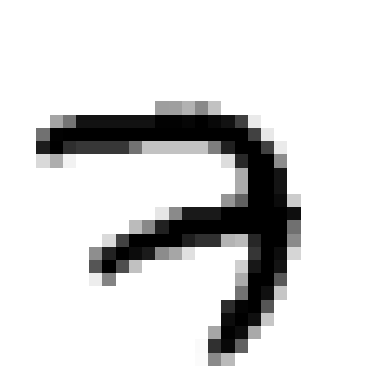

In [115]:
plt.imshow(X_train[0], cmap="binary")
plt.axis('off')
plt.show()

The labels are the class IDs (represented as uint8), from 0 to 9. Conveniently, the class IDs correspond to the digits represented in the images, so we don't need a `class_names` array:

In [116]:
y_train

array([7, 3, 4, ..., 5, 6, 8], dtype=uint8)

The validation set contains 5,000 images, and the test set contains 10,000 images:

In [117]:
X_valid.shape

(5000, 28, 28)

In [118]:
X_test.shape

(10000, 28, 28)

Let's take a look at a sample of the images in the dataset:

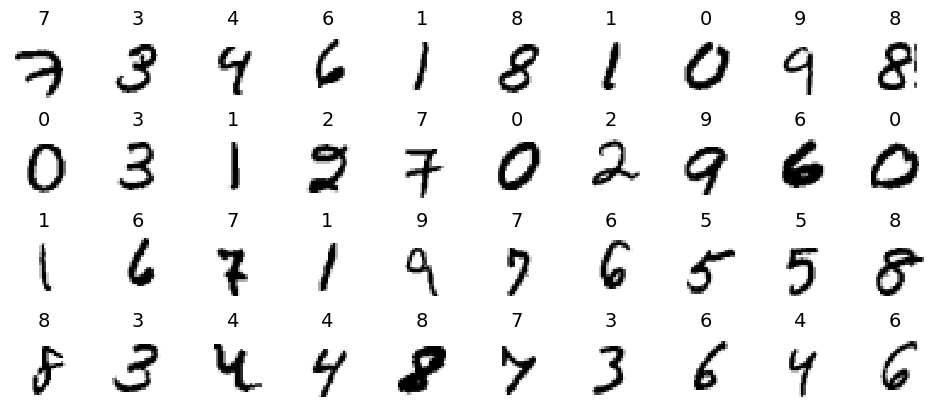

In [119]:
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(y_train[index])
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

Let's build a simple dense network and find the optimal learning rate. We will need a callback to grow the learning rate at each iteration. It will also record the learning rate and the loss at each iteration:

In [120]:
K = tf.keras.backend

class ExponentialLearningRate(tf.keras.callbacks.Callback):
    def __init__(self, factor):
        self.factor = factor
        self.rates = []
        self.losses = []

    def on_batch_end(self, batch, logs=None):
        lr = self.model.optimizer.learning_rate.numpy() * self.factor
        self.model.optimizer.learning_rate = lr
        self.rates.append(lr)
        self.losses.append(logs["loss"])

In [121]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [122]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

We will start with a small learning rate of 1e-3, and grow it by 0.5% at each iteration:

In [123]:
optimizer = tf.keras.optimizers.SGD(learning_rate=1e-3)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
expon_lr = ExponentialLearningRate(factor=1.005)

Now let's train the model for just 1 epoch:

In [124]:
history = model.fit(X_train, y_train, epochs=1,
                    validation_data=(X_valid, y_valid),
                    callbacks=[expon_lr])

1719/1719 [==============================] - 2s 1ms/step - loss: nan - accuracy: 0.5863 - val_loss: nan - val_accuracy: 0.0958


We can now plot the loss as a functionof the learning rate:

Text(0, 0.5, 'Loss')

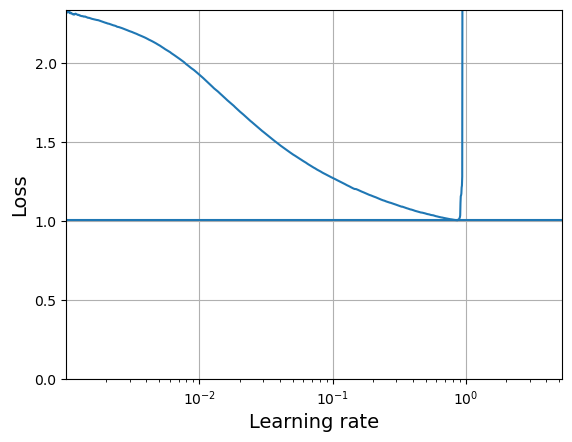

In [125]:
plt.plot(expon_lr.rates, expon_lr.losses)
plt.gca().set_xscale('log')
plt.hlines(min(expon_lr.losses), min(expon_lr.rates), max(expon_lr.rates))
plt.axis([min(expon_lr.rates), max(expon_lr.rates), 0, expon_lr.losses[0]])
plt.grid()
plt.xlabel("Learning rate")
plt.ylabel("Loss")

The loss starts shooting back up violently when the learning rate goes over 6e-1, so let's try using half of that, at 3e-1:

In [126]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [127]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [128]:
optimizer = tf.keras.optimizers.SGD(learning_rate=3e-1)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

In [129]:
run_index = 1 # increment this at every run
run_logdir = Path() / "my_mnist_logs" / "run_{:03d}".format(run_index)
run_logdir

PosixPath('my_mnist_logs/run_001')

In [134]:
import tensorflow as tf
import keras

print("tf:", tf.__version__)
print("keras:", keras.__version__)


tf: 2.14.1
keras: 2.14.0


In [137]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=False)

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "my_mnist_model.h5",
    save_best_only=True
)

tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)

history = model.fit(
    X_train, y_train, epochs=100,
    validation_data=(X_valid, y_valid),
    callbacks=[checkpoint_cb, early_stopping_cb, tensorboard_cb]
)

Epoch 1/100
1719/1719 [==============================] - 2s 988us/step - loss: 0.0186 - accuracy: 0.9939 - val_loss: 0.0842 - val_accuracy: 0.9802
Epoch 2/100
 164/1719 [=>............................] - ETA: 1s - loss: 0.0132 - accuracy: 0.9964

/opt/homebrew/anaconda3/envs/homl3/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1719/1719 [==============================] - 2s 973us/step - loss: 0.0147 - accuracy: 0.9952 - val_loss: 0.1224 - val_accuracy: 0.9742
Epoch 3/100
1719/1719 [==============================] - 2s 971us/step - loss: 0.0102 - accuracy: 0.9969 - val_loss: 0.0854 - val_accuracy: 0.9816
Epoch 4/100
1719/1719 [==============================] - 2s 993us/step - loss: 0.0064 - accuracy: 0.9980 - val_loss: 0.0810 - val_accuracy: 0.9838
Epoch 5/100
1719/1719 [==============================] - 2s 966us/step - loss: 0.0032 - accuracy: 0.9991 - val_loss: 0.0956 - val_accuracy: 0.9834
Epoch 6/100
1719/1719 [==============================] - 2s 970us/step - loss: 0.0083 - accuracy: 0.9975 - val_loss: 0.0902 - val_accuracy: 0.9822
Epoch 7/100
1719/1719 [==============================] - 2s 977us/step - loss: 0.0114 - accuracy: 0.9965 - val_loss: 0.0883 - val_accuracy: 0.9842
Epoch 8/100
1719/1719 [==============================] - 2s 989us/step - loss: 0.0036 - accuracy: 0.9987 - val_loss: 0.0807 - val_

In [136]:
model = tf.keras.models.load_model("my_mnist_model.h5")  # rollback do best z checkpointu
model.evaluate(X_test, y_test)

OSError: No file or directory found at my_mnist_model.h5

We got over 98% accuracy. Finally, let's look at the learning curves using TensorBoard:

In [ ]:
%tensorboard --logdir=./my_mnist_logs